# **Revenue / Demand Forecasting System**

---

## **Executive Summary**

This project presents the development of a time-series forecasting system designed to predict future revenue based on historical demand patterns. Unlike traditional machine learning tasks, forecasting requires strict temporal awareness, where models must rely only on past data to predict future outcomes.

The system leverages historical sales data along with external influencing factors such as pricing and promotional activity to generate accurate short-term forecasts. The objective is to predict the next 90 days of revenue while maintaining robustness against noise, seasonality, and trend variations.

The project begins with detailed time-series exploratory analysis to uncover patterns such as trend, weekly cycles, and seasonal fluctuations. Feature engineering plays a central role, including the creation of lag features, rolling statistics, and calendar-based variables.

Multiple regression models are evaluated, starting from simple linear models to more advanced tree-based algorithms. Special emphasis is placed on avoiding data leakage, a critical issue in time-series modeling, by ensuring that all features are derived strictly from past information.

A proper backtesting framework is implemented using time-based validation techniques, allowing the model to be evaluated in realistic forecasting scenarios. The final system supports multi-step forecasting, generating predictions for the next three months using a recursive approach.

This system is designed to be production-ready, with capabilities for automated retraining, performance monitoring, and API-based deployment. It can be used for real-world applications such as inventory planning, revenue estimation, and demand management.

---

## **1. Business Problem**

Organizations rely on accurate demand forecasts to make critical operational and financial decisions. Poor forecasting can lead to stockouts, overstocking, inefficient resource allocation, and lost revenue opportunities.

Key challenges in demand forecasting include:

* Temporal dependency (future depends on past)
* Seasonality and trend variations
* Impact of external factors (price changes, promotions)
* Noise and irregular fluctuations in demand
* Risk of data leakage in model development

The objective is to build a system that can reliably forecast future demand while capturing both historical patterns and external drivers of sales.

---

## **2. ML Formulation**

### A) Forecasting → Regression Problem

Predict future sales values (continuous variable) based on historical observations.

### B) Time-Series Constraint

Unlike standard regression:

* Data must be processed sequentially
* Future data must never influence past predictions
* Validation must respect temporal ordering

---

## **Methodology Overview**

The project follows a structured, production-oriented workflow:

### 1. Data Understanding & Time Analysis

Explore trends, seasonality, and temporal patterns in sales data.

### 2. Feature Engineering

Create lag features, rolling statistics, and calendar-based variables.

### 3. Model Development

Train regression models to predict future sales.

### 4. Temporal Validation

Use time-based cross-validation (e.g., TimeSeriesSplit) to simulate real-world forecasting.

### 5. Multi-Step Forecasting

Generate predictions for multiple future time steps (90-day horizon).

### 6. Backtesting

Evaluate model performance using rolling forecast windows.

### 7. Deployment Preparation

Prepare model pipeline for API-based serving and retraining.

---

## **3. Target Variable**

Sales (Daily Revenue / Demand)

---

## **4. Success Metrics**

Forecasting performance is evaluated using error-based metrics:

### Primary Metric

* **MAE (Mean Absolute Error)**
  Measures average prediction error in real units.

### Secondary Metric

* **RMSE (Root Mean Squared Error)**
  Penalizes large prediction errors more heavily.

### Evaluation Strategy

* Backtesting across multiple time windows
* Stability of error over time
* Consistency across different demand patterns

---

## **5. Final Output**

For each forecasting request, the system outputs:

* Predicted sales for the next 90 days
* Evaluation metrics (MAE, RMSE)
* Historical vs predicted comparison (for analysis)

---

## **Project Goal**

To develop a production-ready forecasting system that accurately predicts future demand using time-aware machine learning techniques, enabling better business decision-making and operational planning.

---

## **About Dataset**

This dataset contains synthetic daily retail sales data spanning January 2019 to December 2023.
It simulates realistic demand patterns across multiple stores and items, incorporating
trend, seasonality, pricing, and promotional effects.

**Key Characteristics**
- Granularity: Daily sales
- Entities: 50 stores × 50 items
- Time span: 5 years (2019–2023)
- Observations: Store–item–day level

**Features**
- date: Calendar date of the observation
- store_id: Unique store identifier
- item_id: Unique item identifier
- sales: Number of units sold on that day
- price: Item price (adjusted during promotions)
- promo: Promotion flag (1 = active, 0 = no promotion)
- weekday: Day of the week (0 = Monday, 6 = Sunday)
- month: Month of the year (1–12)

---

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---

## Data Acquisition

In [2]:
df = pd.read_csv('data/retail_sales.csv')
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [5]:
df.shape

(4565000, 8)

In [7]:
df.describe()

,sales,price,promo,weekday,month
count,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06
mean,2.926466e+01,5.399323e+01,9.999869e-02,3.001643e+00,6.523549e+00
std,1.500996e+01,2.578461e+01,2.999983e-01,1.999315e+00,3.448534e+00
min,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.800000e+01,3.197000e+01,0.000000e+00,1.000000e+00,4.000000e+00
50%,2.700000e+01,5.352000e+01,0.000000e+00,3.000000e+00,7.000000e+00
75%,3.800000e+01,7.536000e+01,0.000000e+00,5.000000e+00,1.000000e+01
max,1.390000e+02,9.999000e+01,1.000000e+00,6.000000e+00,1.200000e+01


In [25]:
df.isna().sum()

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

---

## Data Transformation

Let us first convert date to date time type instead of object, as we need the data to be sorted by the date

In [8]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype         
---  ------    -----         
 0   date      datetime64[ns]
 1   store_id  object        
 2   item_id   object        
 3   sales     int64         
 4   price     float64       
 5   promo     int64         
 6   weekday   int64         
 7   month     int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 278.6+ MB


In [12]:
df = df.sort_values(by='date')

In [13]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
483890,2019-01-01,store_6,item_16,27,78.57,0,1,1
3515050,2019-01-01,store_39,item_26,47,31.60,0,1,1
3516876,2019-01-01,store_39,item_27,34,17.33,0,1,1
3518702,2019-01-01,store_39,item_28,19,35.23,1,1,1


## EDA

At this stage, the dataset contains multiple records per date, representing store–item level transactions. This structure is suitable for transactional analysis but not for time-series forecasting, where a single observation per time step is required.

To convert the data into a proper time-series format, we aggregate the total sales by date. This transformation reduces the dataset to one observation per day, enabling the analysis of overall demand patterns such as trend and seasonality.

In [20]:
grouped_df = df.groupby('date').sum()['sales'].reset_index()

In [21]:
grouped_df.head()

,date,sales
0,2019-01-01,74119
1,2019-01-02,77119
2,2019-01-03,70810
3,2019-01-04,59269
4,2019-01-05,52621


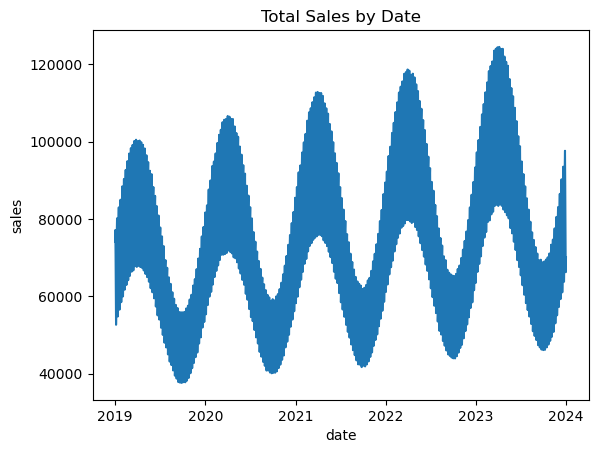

In [22]:
sns.lineplot(data=grouped_df, x='date', y='sales')
plt.title('Total Sales by Date')
plt.show()

The time series shows a clear upward trend along with strong yearly seasonality. The pattern repeats consistently each year, indicating predictable demand cycles. The data appears smooth with minimal noise, suggesting a strong underlying signal that is well-suited for forecasting. However, the presence of a trend means the series is non-stationary, which should be considered during modeling.


Let us now observe the 7 day rolling average of sales, along with the original sales